In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from  spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize as wordTokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# plot options
plt.rcParams["figure.figsize"] = (12,8)
dpc = "#00bfbf" # default plot colour

In [3]:
data = pd.read_csv("fake_news_data.csv")
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 1.0, 'Count of article classification')

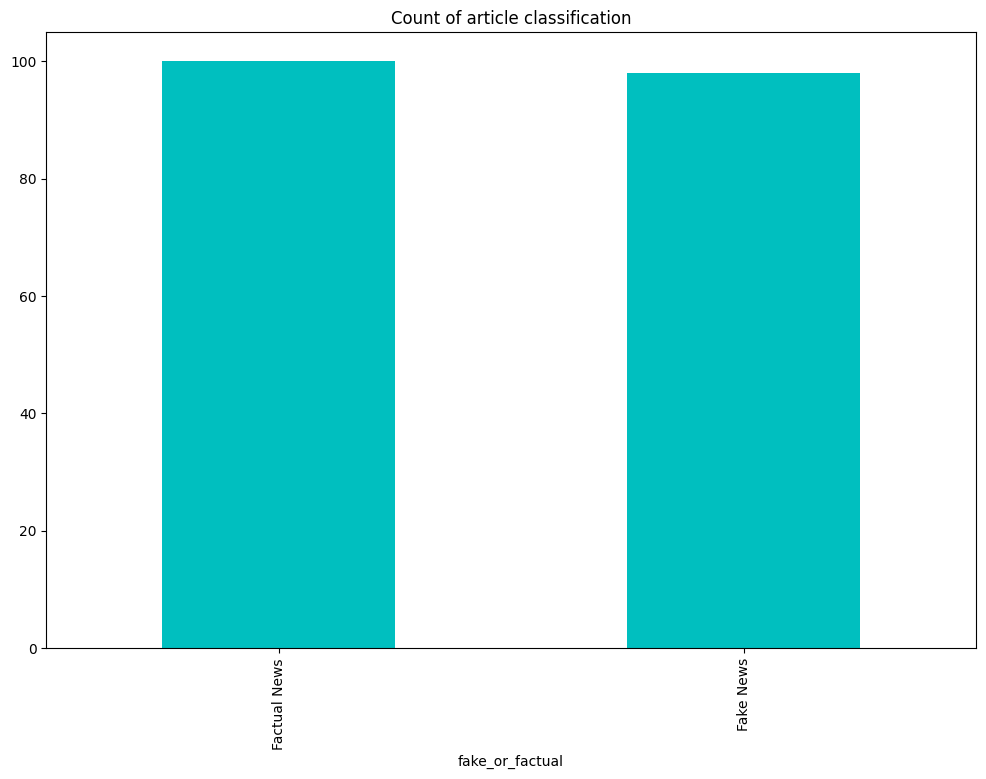

In [5]:
data["fake_or_factual"].value_counts().plot(kind="bar", color=dpc)
plt.title("Count of article classification")
# same number, perfect for analysis

### POS tagging

In [6]:
nlp = spacy.load("en_core_web_sm")

In [7]:
fakeNews = data[data["fake_or_factual"] == "Fake News"]
factualNews = data[data["fake_or_factual"] == "Factual News"]

In [8]:
fakeSpacyDocs = list(nlp.pipe(fakeNews["text"]))
factualSpacyDocs = list(nlp.pipe(factualNews["text"]))

In [9]:
def extractTokenTags(doc:spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc] 

In [10]:
fakeTagsDf = []
columns = ["token", "nerTag", "posTag"]
for ix, doc in enumerate(fakeSpacyDocs):
    tags = extractTokenTags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fakeTagsDf.append(tags)
fakeTagsDf = pd.concat(fakeTagsDf)

In [11]:
factualTagsDf = []
for ix, doc in enumerate(factualSpacyDocs):
    tags = extractTokenTags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    factualTagsDf.append(tags)
factualTagsDf = pd.concat(factualTagsDf)

In [12]:
fakeTagsDf.head()

,token,nerTag,posTag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [13]:
posCountsFake = fakeTagsDf.groupby(["token", "posTag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
posCountsFake.head(10)

,token,posTag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [14]:
posCountsFactual = factualTagsDf.groupby(["token", "posTag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
posCountsFactual.head(10)

,token,posTag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [15]:
posCountsFake.groupby("posTag").token.count().sort_values(ascending = False)

posTag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64

In [16]:
posCountsFactual.groupby("posTag").token.count().sort_values(ascending = False)

posTag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
SPACE      11
CCONJ      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64

In [17]:
posCountsFake[posCountsFake.posTag == "NOUN"][:15]

,token,posTag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [18]:
posCountsFactual[posCountsFactual.posTag == "NOUN"][:15]

,token,posTag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
4259,law,NOUN,42


### Named entities

In [19]:
topEntitiesFake = fakeTagsDf[fakeTagsDf.nerTag != ""].groupby(["token", "nerTag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)

In [20]:
topEntitiesFactual = factualTagsDf[factualTagsDf.nerTag != ""].groupby(["token", "nerTag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)

In [21]:
nerPalette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most common entities in fake news')]

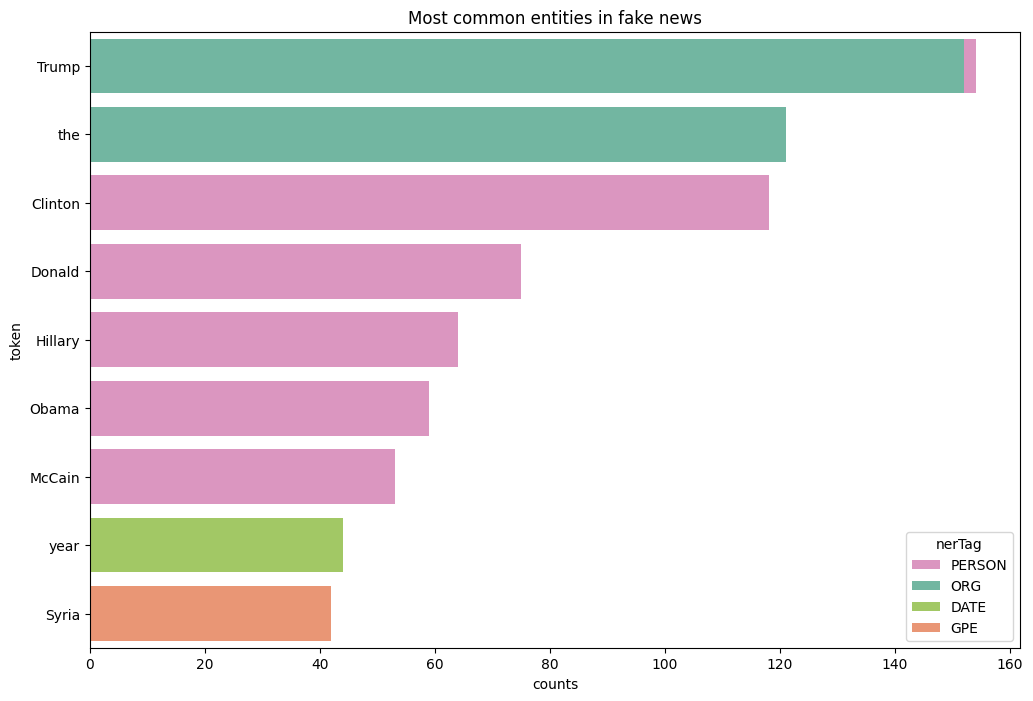

In [22]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'nerTag',
    palette = nerPalette,
    data = topEntitiesFake[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most common entities in fake news')

[Text(0.5, 1.0, 'Most common entities in factual news')]

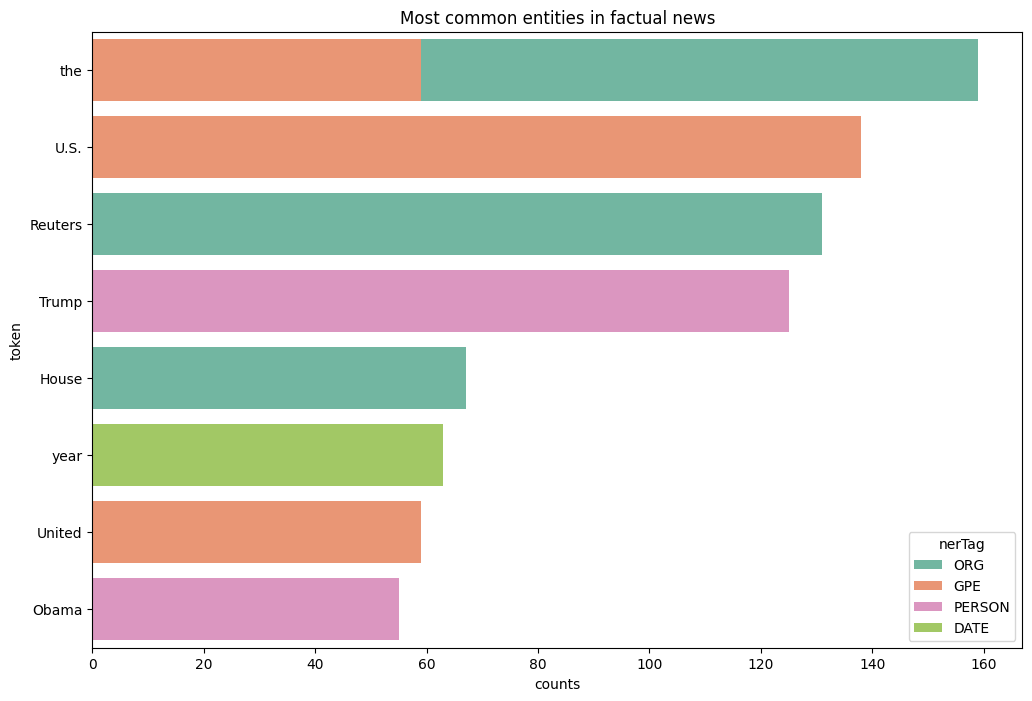

In [23]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'nerTag',
    palette = nerPalette,
    data = topEntitiesFactual[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most common entities in factual news')

### Text preprocessing

In [24]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [25]:
data["textClean"] = data.apply(lambda x:re.sub(r"^[^-]*-\s", "", x["text"]), axis = 1) # remove text before the first hypen (-)

In [26]:
data["textClean"] = data["textClean"].str.lower()
data["textClean"] = data["textClean"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [27]:
enStopwords = stopwords.words("english")
data["textClean"] = data["textClean"].apply(lambda x: " ".join([word for word in x.split() if word not in enStopwords]))

In [28]:
data["textClean"] = data.apply(lambda x: wordTokenize(x["textClean"]), axis = 1)

In [29]:
lemmatizer = WordNetLemmatizer()
data["textClean"] = data["textClean"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [30]:
tokensClean = sum(data["textClean"], [])
unigrams =(pd.Series(nltk.ngrams(tokensClean, 1)).value_counts()).reset_index()
unigrams[:10]

,index,count
0,"(said,)",580
1,"(trump,)",580
2,"(u,)",277
3,"(state,)",275
4,"(president,)",259
5,"(would,)",226
6,"(one,)",160
7,"(clinton,)",141
8,"(year,)",139
9,"(republican,)",137


In [31]:
#unigrams["token"] = unigrams["index"].apply(lambda x:x[0]) # extract the token from the tuple so we can plot it

#sns.barplot(x="count",
#            y="token",
#            data=unigrams,
#            orient="h",
 #           palette=[dpc],
  #          hue="token", legend=False
#).set(title="Most common unigrams after preprocessing")

### Sentiment analysis

In [32]:
vaderSent = SentimentIntensityAnalyzer()

In [33]:
data["vaderSentScore"] = data["text"].apply(lambda x:vaderSent.polarity_scores(x)["compound"])
data.head()

,title,text,date,fake_or_factual,textClean,vaderSentScore
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [34]:
bins = [-1,-0.1, 0.1, 1]
names = ["negative", "neutral", "positive"]

In [35]:
data["vaderSentLabel"] = pd.cut(data["vaderSentScore"], bins, labels = names)
data.head()

,title,text,date,fake_or_factual,textClean,vaderSentScore,vaderSentLabel
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


<Axes: xlabel='vaderSentLabel'>

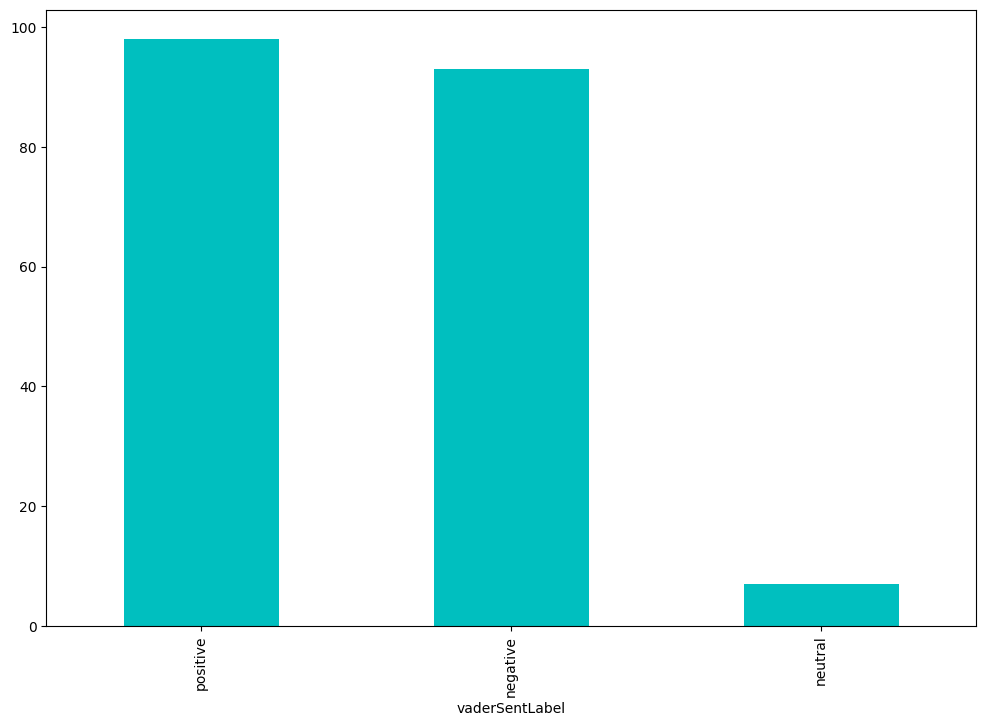

In [36]:
data["vaderSentLabel"].value_counts().plot.bar(color=dpc)

C:\Users\Josip\AppData\Local\Temp\ipykernel_27968\2937848967.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by news type')]

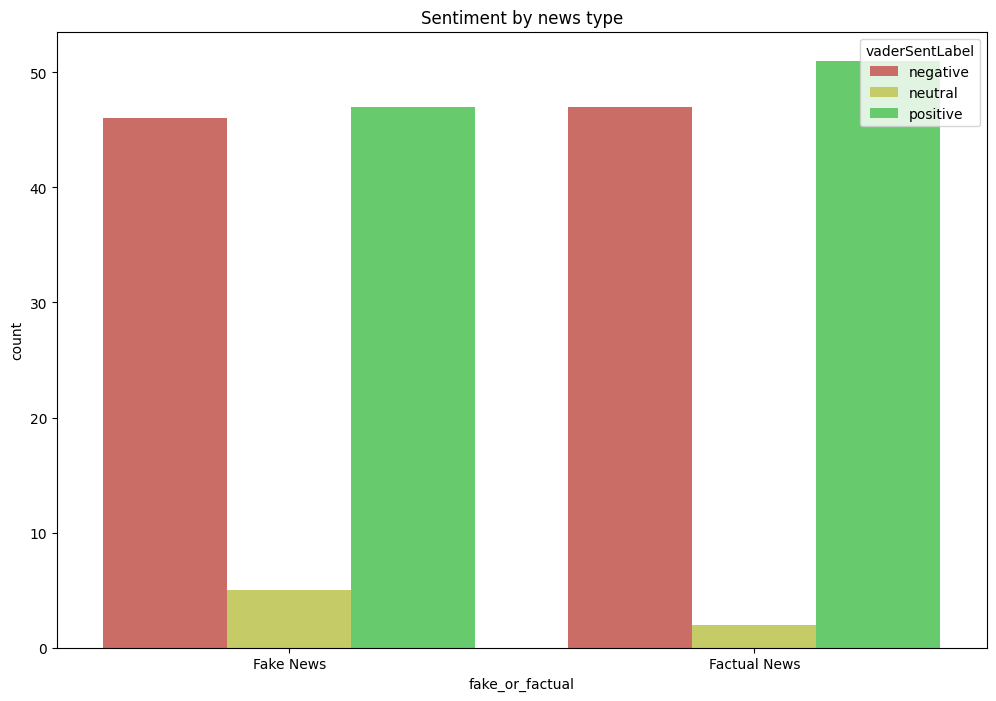

In [37]:
sns.countplot(
    x="fake_or_factual",
    hue="vaderSentLabel",
    palette=sns.color_palette("hls"),
    data=data
).set(title="Sentiment by news type")

### Topic modelling

In [38]:
# vectorizing
fakeNewsText = data[data["fake_or_factual"] == "Fake News"]["textClean"].reset_index(drop=True)

In [39]:
dictionaryFake = corpora.Dictionary(fakeNewsText)

In [40]:
docTermFake = [dictionaryFake.doc2bow(text) for text in fakeNewsText]

In [41]:
coherenceValues = []
modelList = []
minTopics = 2
maxTopics = 11

for numTopicsIdx in range(minTopics, maxTopics + 1):
    model = gensim.models.LdaModel(docTermFake, num_topics = numTopicsIdx, id2word = dictionaryFake)
    modelList.append(model)
    coherenceModel = CoherenceModel(model= model, texts = fakeNewsText, dictionary = dictionaryFake, coherence="c_v")
    coherenceValues.append(coherenceModel.get_coherence())

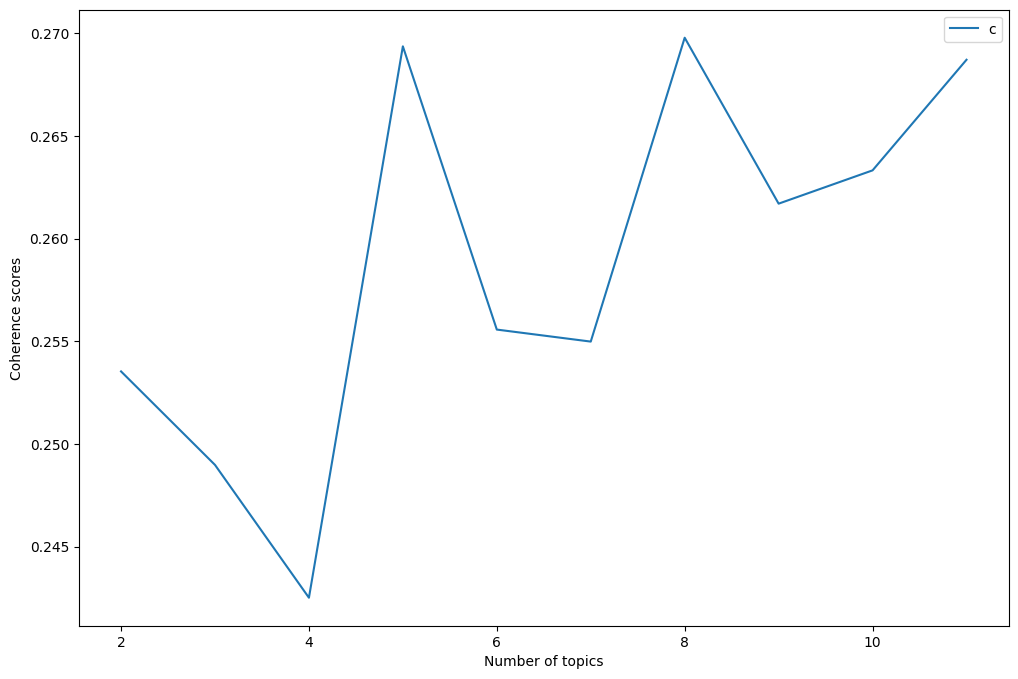

In [42]:
plt.plot(range(minTopics, maxTopics + 1), coherenceValues)
plt.xlabel("Number of topics")
plt.ylabel("Coherence scores")
plt.legend(("coherenceValues"), loc = "best")
plt.show()

In [43]:
numTopics = 7
ldaModel = gensim.models.LdaModel(corpus = docTermFake, id2word = dictionaryFake, num_topics = numTopics)

In [44]:
ldaModel.print_topics(num_topics = numTopics, num_words=10)

[(0,
  '0.007*"trump" + 0.005*"said" + 0.004*"clinton" + 0.004*"u" + 0.003*"president" + 0.003*"would" + 0.003*"state" + 0.003*"woman" + 0.003*"people" + 0.003*"one"'),
 (1,
  '0.016*"trump" + 0.006*"said" + 0.005*"clinton" + 0.004*"would" + 0.004*"u" + 0.004*"one" + 0.004*"donald" + 0.004*"mccain" + 0.004*"president" + 0.003*"time"'),
 (2,
  '0.007*"trump" + 0.005*"said" + 0.005*"clinton" + 0.003*"year" + 0.003*"would" + 0.003*"u" + 0.003*"official" + 0.003*"state" + 0.003*"american" + 0.003*"one"'),
 (3,
  '0.010*"trump" + 0.005*"president" + 0.005*"said" + 0.005*"clinton" + 0.004*"donald" + 0.004*"one" + 0.004*"time" + 0.004*"would" + 0.003*"u" + 0.003*"state"'),
 (4,
  '0.014*"trump" + 0.004*"president" + 0.004*"said" + 0.004*"state" + 0.004*"obama" + 0.004*"republican" + 0.003*"party" + 0.003*"one" + 0.003*"u" + 0.002*"time"'),
 (5,
  '0.013*"trump" + 0.006*"state" + 0.005*"president" + 0.005*"said" + 0.004*"clinton" + 0.004*"woman" + 0.004*"people" + 0.004*"would" + 0.003*"republ

In [45]:
def tfidfCorpus(docTermMatrix):
    tfidf = TfidfModel(corpus = docTermMatrix, normalize = True)
    corpusTfidf = tfidf[docTermMatrix]
    return corpusTfidf

In [46]:
def getCoherenceScores(corpus, dictionary, text, minTopics, maxTopics):
    coherenceValues = []
    modelList = []
    for numTopicsIdx in range(minTopics, maxTopics + 1):
        model = LsiModel(corpus, num_topics = numTopicsIdx, id2word = dictionary)
        modelList.append(model)
        coherenceModel = CoherenceModel(model= model, texts = text, dictionary=dictionary, coherence="c_v")
        coherenceValues.append(coherenceModel.get_coherence())

    plt.plot(range(minTopics, maxTopics + 1), coherenceValues)
    plt.xlabel("Number of topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherenceValues"), loc="best")
    plt.show()

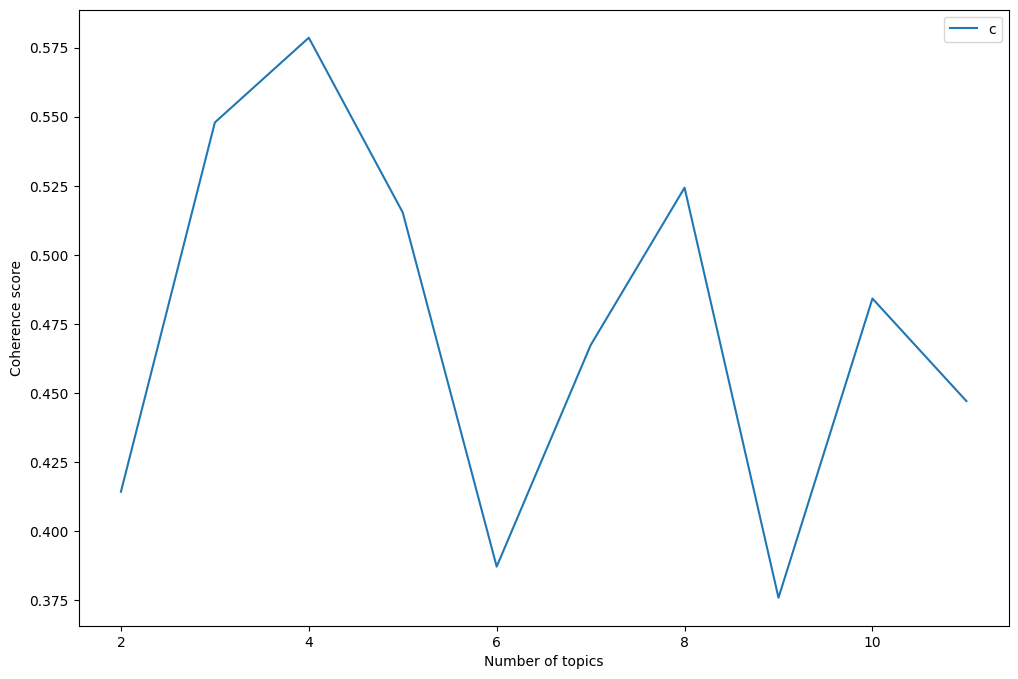

In [47]:
corpusTfidfFake = tfidfCorpus(docTermFake)
getCoherenceScores(corpusTfidfFake, dictionaryFake, fakeNewsText, minTopics = 2, maxTopics = 11)

In [48]:
lsaModel = LsiModel(corpusTfidfFake, id2word = dictionaryFake, num_topics = 3)

In [49]:
lsaModel.print_topics()

[(0,
  '-0.190*"trump" + -0.136*"clinton" + -0.095*"hillary" + -0.094*"obama" + -0.089*"president" + -0.087*"woman" + -0.078*"republican" + -0.077*"party" + -0.077*"flynn" + -0.074*"candidate"'),
 (1,
  '0.325*"boiler" + 0.284*"acr" + 0.244*"room" + 0.240*"pm" + 0.186*"broadcast" + 0.180*"radio" + 0.142*"tune" + 0.142*"animal" + 0.134*"jay" + 0.132*"episode"'),
 (2,
  '-0.623*"flynn" + -0.182*"immunity" + -0.122*"nana" + -0.116*"mr" + -0.110*"30" + -0.108*"march" + -0.102*"russian" + -0.100*"source" + 0.095*"school" + -0.092*"adviser"')]

In [50]:
# Classification model

In [51]:
data.head()

,title,text,date,fake_or_factual,textClean,vaderSentScore,vaderSentLabel
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


In [53]:
x = [",".join(map(str, l)) for l in data["textClean"]]
y = data["fake_or_factual"]

In [54]:
countVec = CountVectorizer()

In [55]:
countVecFit = countVec.fit_transform(x)

In [58]:
bagOfWords = pd.DataFrame(countVecFit.toarray(), columns= countVec.get_feature_names_out())

In [59]:
xTrain, xTest, yTrain, yTest = train_test_split(bagOfWords, y, test_size = 0.3)

In [60]:
lr = LogisticRegression(random_state=0).fit(xTrain, yTrain)

In [61]:
yPredLr = lr.predict(xTest)

In [62]:
accuracy_score(yPredLr, yTest)

0.85

In [64]:
print(classification_report(yTest, yPredLr))

              precision    recall  f1-score   support

Factual News       0.83      0.86      0.84        28
   Fake News       0.87      0.84      0.86        32

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



In [65]:
svm = SGDClassifier().fit(xTrain, yTrain)

In [67]:
yPredSvm = svm.predict(xTest)

In [68]:
accuracy_score(yPredSvm, yTest)

0.8

In [69]:
print(classification_report(yTest, yPredSvm))

              precision    recall  f1-score   support

Factual News       0.86      0.68      0.76        28
   Fake News       0.76      0.91      0.83        32

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.79        60
weighted avg       0.81      0.80      0.80        60

